# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [2]:
# Import the library
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline


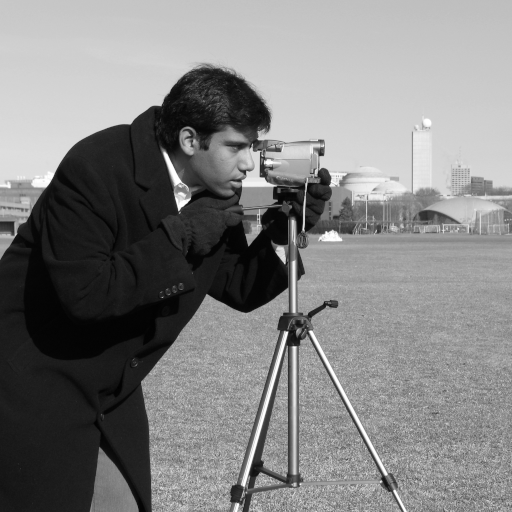

In [13]:
# ── Load image ────────────────────────────────────
image = data.camera()
image = Image.fromarray(image)
display(image)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [6]:
# Get the size of the image
width, height = image.size
# scaling factors
factor = 2


In [9]:
width, height = image.size
new_width = width * factor
new_height = height * factor
scaled_image = image.resize((new_width, new_height), Image.LANCZOS)

print(f"Original size: {width}x{height}")
print(f"Scaled size: {new_width}x{new_height}")

Original size: 512x512
Scaled size: 1024x1024


In [8]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_image.save("task1_1_scaled.jpg")
print(f"Saved image 'task1_1_scaled.jpg' with size: {scaled_image.size}")

Saved image 'task1_1_scaled.jpg' with size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

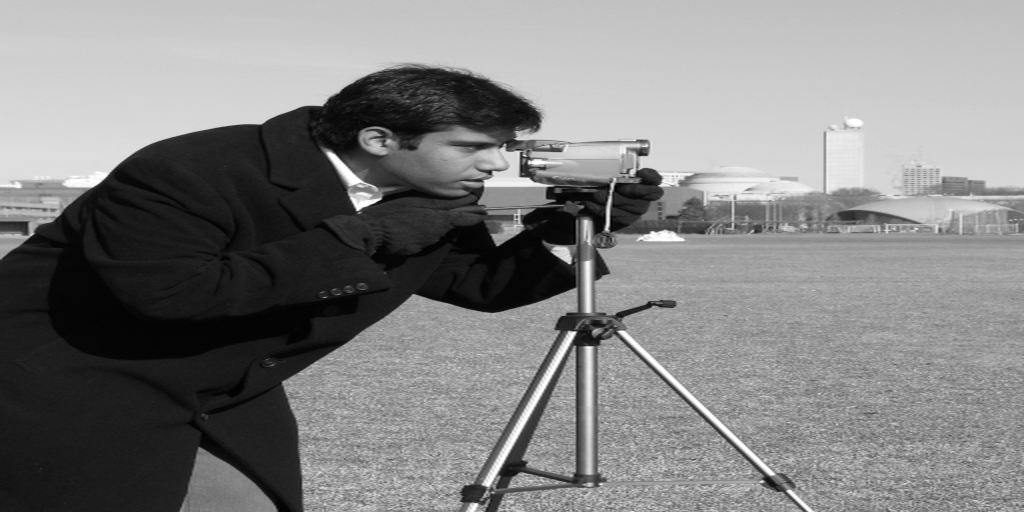

In [12]:
stretch_image = image.resize((new_width, height), Image.LANCZOS)
display(stretch_image)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

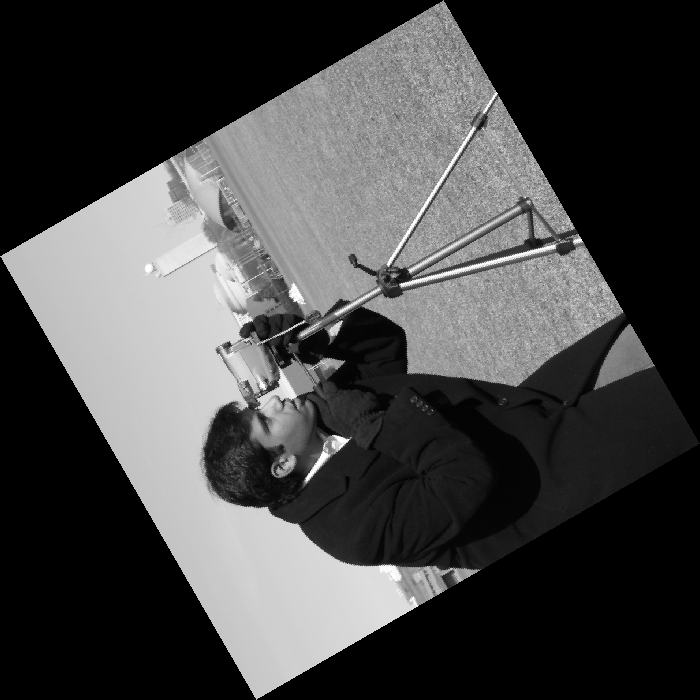

Saved image 'task1_2_rotated.jpg'


In [15]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_image = image.rotate(120, expand=True)
display(rotated_image)
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image.save("task1_2_rotated.jpg")
print(f"Saved image 'task1_2_rotated.jpg'")

### 3. Shear

In [16]:
# -- c. Get the image dimensions ────────────────────
width, height = image.size
print(f"Image dimensions: {width}x{height}")

Image dimensions: 512x512


In [26]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
# Define the shear factor
shear_factor_x = 0.5

forward_shear_matrix = np.array([
    [1, shear_factor_x, 0],
    [0, 1, 0],
    [0, 0, 1]
], dtype=np.float32)

# PIL's Image.transform(Image.AFFINE, ...) expects the INVERSE of the affine matrix.
# The inverse of a simple X-shear matrix [[1, s, 0], [0, 1, 0], [0, 0, 1]] is [[1, -s, 0], [0, 1, 0], [0, 0, 1]].
inverse_shear_matrix = np.array([
    [1, -shear_factor_x, 0],
    [0, 1, 0],
    [0, 0, 1]
], dtype=np.float32)

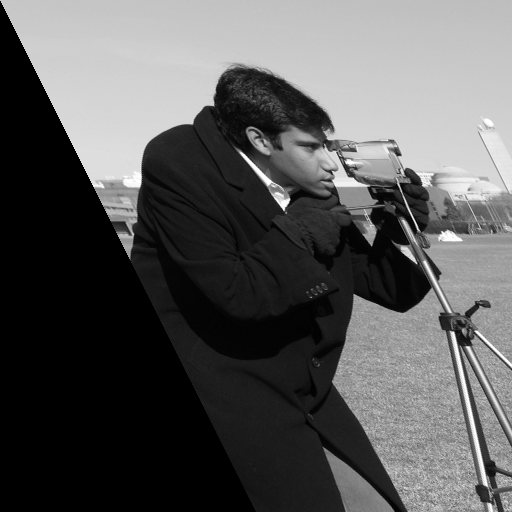

In [27]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ a, b, c ]
# [ d, e, f ]
# Extract the 6-tuple affine matrix from the 3x3 inverse_shear_matrix
a, b, c = inverse_shear_matrix[0, 0], inverse_shear_matrix[0, 1], inverse_shear_matrix[0, 2]
d, e, f = inverse_shear_matrix[1, 0], inverse_shear_matrix[1, 1], inverse_shear_matrix[1, 2]
affine_transform_data = (a, b, c, d, e, f)

sheared_image = image.transform(
    (width, height), Image.AFFINE, affine_transform_data, resample=Image.BICUBIC
)
display(sheared_image)

In [28]:
# -- f. Save the sheared image (The new image name should be "task1_3_sheared.jpg")
sheared_image.save("task1_3_sheared.jpg")
print(f"Saved image 'task1_3_sheared.jpg'")

Saved image 'task1_3_sheared.jpg'


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

Applying X-axis shear with factor: 0.1


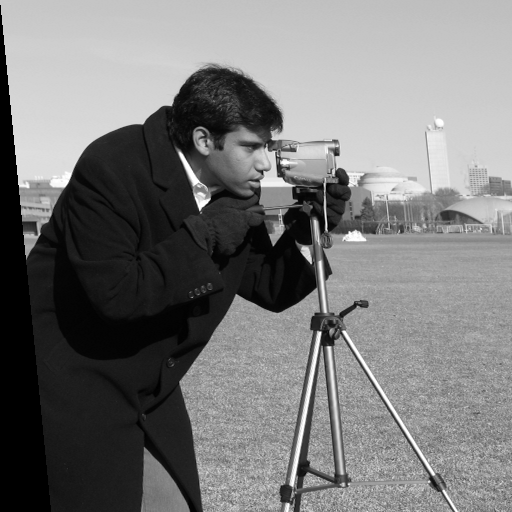

Applying X-axis shear with factor: 0.3


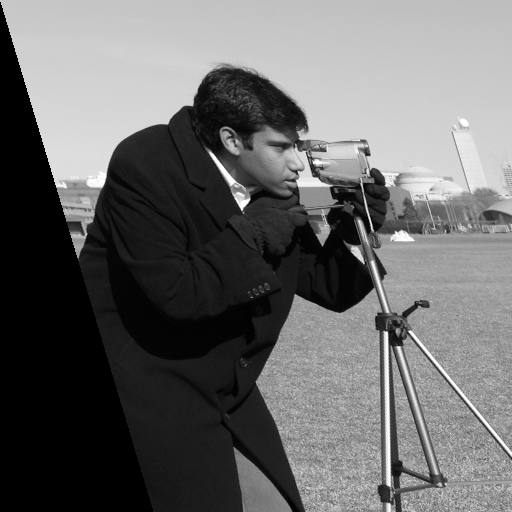

Applying X-axis shear with factor: 0.8


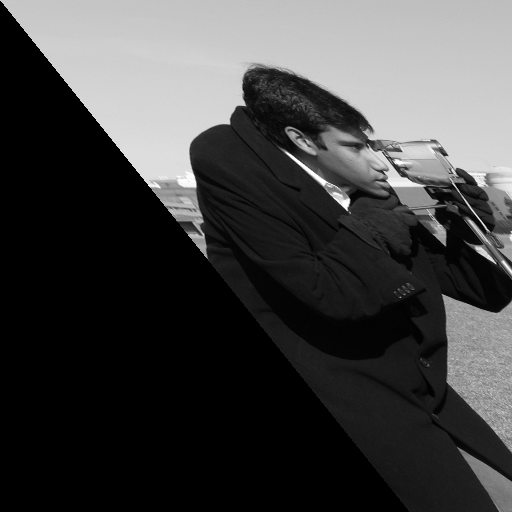

In [38]:
# Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results
shear_factors_x = [0.1, 0.3, 0.8]

for factor_x in shear_factors_x:
    print(f"Applying X-axis shear with factor: {factor_x}")

    # Calculate the inverse shear matrix for the current factor
    inverse_shear_matrix_exp1 = np.array([
        [1, -factor_x, 0],
        [0, 1, 0],
        [0, 0, 1]
    ], dtype=np.float32)

    # Extract the 6-tuple affine matrix
    a, b, c = inverse_shear_matrix_exp1[0, 0], inverse_shear_matrix_exp1[0, 1], inverse_shear_matrix_exp1[0, 2]
    d, e, f = inverse_shear_matrix_exp1[1, 0], inverse_shear_matrix_exp1[1, 1], inverse_shear_matrix_exp1[1, 2]
    affine_transform_data_exp1 = (a, b, c, d, e, f)

    # Apply the transformation
    sheared_image_exp1 = image.transform(
        (width, height), Image.AFFINE, affine_transform_data_exp1, resample=Image.BICUBIC
    )
    display(sheared_image_exp1)

Applying Y-axis shear with factor: 0.5


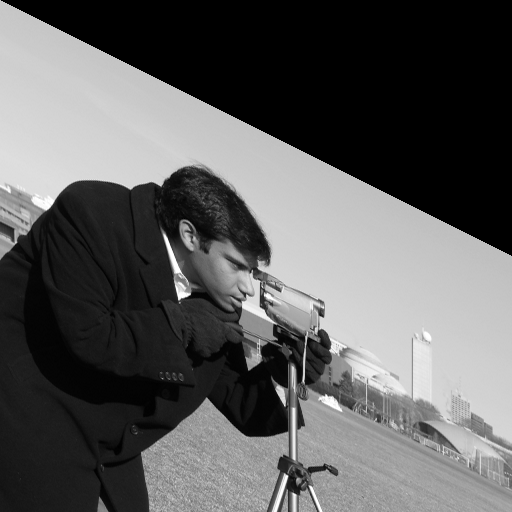

In [39]:
# Switch from X-axis to Y-axis shear matrix
shear_factor_y = 0.5

print(f"Applying Y-axis shear with factor: {shear_factor_y}")

forward_shear_matrix_y = np.array([
    [1, 0, 0],
    [shear_factor_y, 1, 0],
    [0, 0, 1]
], dtype=np.float32)

inverse_shear_matrix_y = np.array([
    [1, 0, 0],
    [-shear_factor_y, 1, 0],
    [0, 0, 1]
], dtype=np.float32)

# Extract the 6-tuple affine matrix
a, b, c = inverse_shear_matrix_y[0, 0], inverse_shear_matrix_y[0, 1], inverse_shear_matrix_y[0, 2]
d, e, f = inverse_shear_matrix_y[1, 0], inverse_shear_matrix_y[1, 1], inverse_shear_matrix_y[1, 2]
affine_transform_data_y = (a, b, c, d, e, f)

sheared_image_y = image.transform(
    (width, height), Image.AFFINE, affine_transform_data_y, resample=Image.BICUBIC
)
display(sheared_image_y)

Original dimensions: 512x512
New canvas dimensions: 921x512


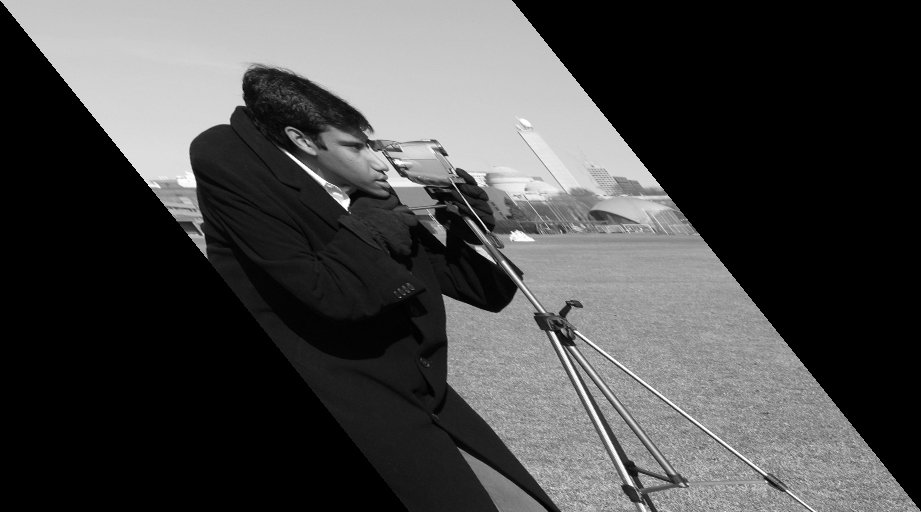

In [41]:
# Update the canvas multiplier to match your new factor
shear_factor_x_canvas = 0.8

# Calculate new canvas dimensions to fit the sheared image
new_canvas_width = int(width + abs(shear_factor_x_canvas * height))
new_canvas_height = height # height stays the same if we do an x-axis shear

print(f"Original dimensions: {width}x{height}")
print(f"New canvas dimensions: {new_canvas_width}x{new_canvas_height}")

inverse_shear_matrix_canvas = np.array([
    [1, -shear_factor_x_canvas, 0],
    [0, 1, 0],
    [0, 0, 1]
], dtype=np.float32)

a, b, c = inverse_shear_matrix_canvas[0, 0], inverse_shear_matrix_canvas[0, 1], inverse_shear_matrix_canvas[0, 2]
d, e, f = inverse_shear_matrix_canvas[1, 0], inverse_shear_matrix_canvas[1, 1], inverse_shear_matrix_canvas[1, 2]
affine_transform_data_canvas = (a, b, c, d, e, f)

sheared_image_canvas = image.transform(
    (new_canvas_width, new_canvas_height), Image.AFFINE, affine_transform_data_canvas, resample=Image.BICUBIC
)
display(sheared_image_canvas)

Applying combined X-axis shear (0.3) and Y-axis shear (0.2)


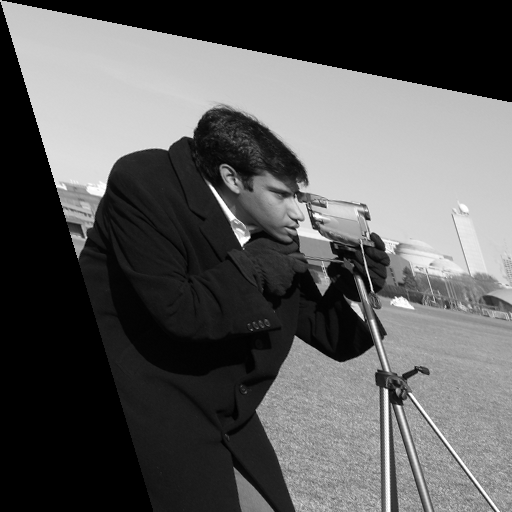

In [42]:
# Try combining X and Y shear in one matrix

shear_factor_x_combined = 0.3
shear_factor_y_combined = 0.2

print(f"Applying combined X-axis shear ({shear_factor_x_combined}) and Y-axis shear ({shear_factor_y_combined})")

shear_matrix_combined = np.array([
    [1, shear_factor_x_combined, 0],
    [shear_factor_y_combined, 1, 0],
    [0, 0, 1]
], dtype=np.float32)

# Calculate the inverse of the 2x2 part of the shear matrix
det = 1 - (shear_factor_x_combined * shear_factor_y_combined)

if det == 0:
    print("Cannot apply combined shear: determinant is zero (shear_factor_x * shear_factor_y == 1)")
else:
    inv_det = 1 / det
    inverse_shear_matrix_combined = np.array([
        [inv_det, -shear_factor_x_combined * inv_det, 0],
        [-shear_factor_y_combined * inv_det, inv_det, 0],
        [0, 0, 1]
    ], dtype=np.float32)

    # Extract the 6-tuple affine matrix
    a, b, c = inverse_shear_matrix_combined[0, 0], inverse_shear_matrix_combined[0, 1], inverse_shear_matrix_combined[0, 2]
    d, e, f = inverse_shear_matrix_combined[1, 0], inverse_shear_matrix_combined[1, 1], inverse_shear_matrix_combined[1, 2]
    affine_transform_data_combined = (a, b, c, d, e, f)

    # Apply the transformation
    sheared_image_combined = image.transform(
        (width, height), Image.AFFINE, affine_transform_data_combined, resample=Image.BICUBIC
    )
    display(sheared_image_combined)

# Intensity Transformations
Negative · Log · Power Law (Gamma)

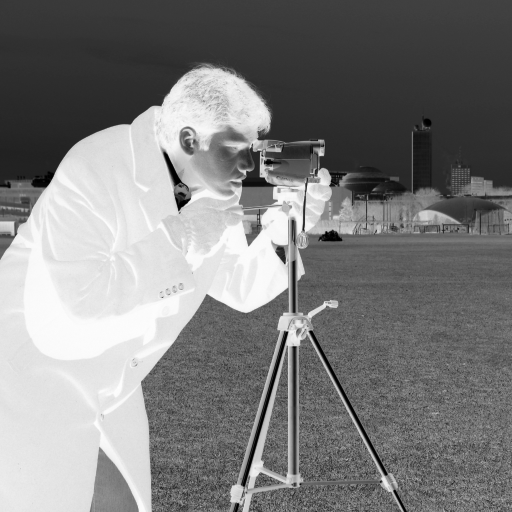

In [43]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation

image_array = np.array(image)
negative_array = 255 - image_array
negative_image_np = Image.fromarray(negative_array.astype(np.uint8))

display(negative_image_np)

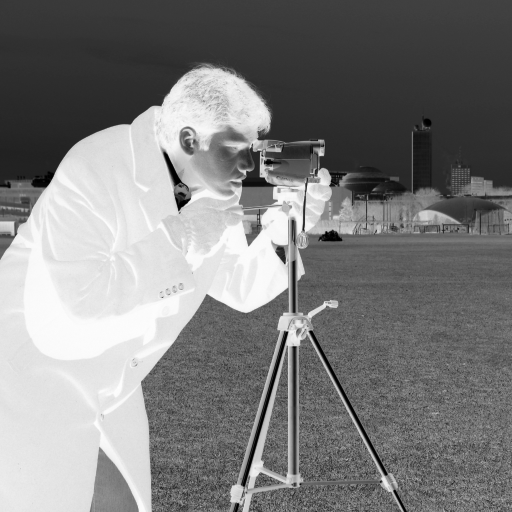

In [44]:
# Method 2: PIL's ImageOps

from PIL import ImageOps
negative_image_pil = ImageOps.invert(image)
display(negative_image_pil)

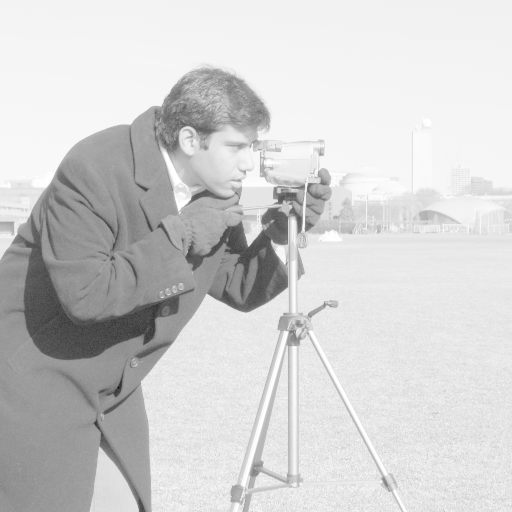

In [45]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

# Convert image to NumPy array for processing
arr = np.array(image, dtype=np.float32)

# Calculate constant c
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr)

# Convert back to uint8 and then to PIL Image
log_transformed_image = Image.fromarray(log_transformed_arr.astype(np.uint8))
display(log_transformed_image)

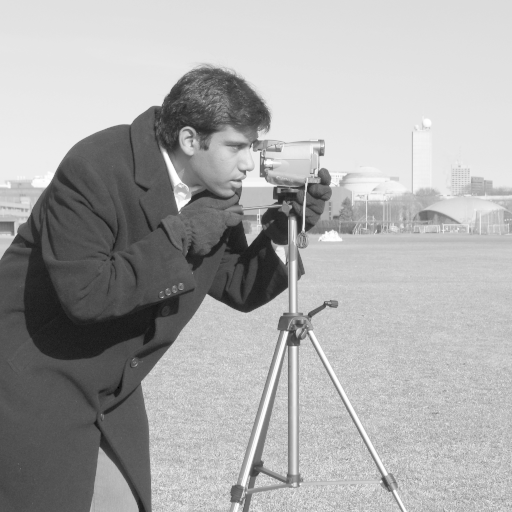

Applied Gamma Correction with gamma = 0.5


In [36]:
# ── 3. Power-law / Gamma correction ───────────────

# s = c * r^gamma
arr = np.array(image, dtype=np.float32)
gamma = 0.5

# Apply the power-law transformation
gamma_corrected_arr = 255 * np.power(arr / 255, gamma)

gamma_corrected_image = Image.fromarray(gamma_corrected_arr.astype(np.uint8))
display(gamma_corrected_image)

print(f"Applied Gamma Correction with gamma = {gamma}")